In [8]:
# Open training, testing subsets from https://doi.org/10.1021/acs.energyfuels.0c01533
from csv import DictReader

with open('schweidtmann_train.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    compounds_train = [r for r in reader]
csv_file.close()
with open('schweidtmann_test.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    compounds_test = [r for r in reader]
csv_file.close()

print(len(compounds_train), len(compounds_test))

# Filter out compounds with `n.a.` RON or MON data
compounds_train = [c for c in compounds_train if c['Meas RON'] != 'n.a.' and c['Meas MON'] != 'n.a.']
compounds_test = [c for c in compounds_test if c['Meas RON'] != 'n.a.' and c['Meas MON'] != 'n.a.']

print(len(compounds_train), len(compounds_test))

430 75
265 51


In [9]:
# Format data for training
from ecnet.datasets.structs import QSPRDataset

smiles_train = [c[' SMILES'] for c in compounds_train]
ron_train = [float(c['Meas RON']) for c in compounds_train]
mon_train = [float(c['Meas MON']) for c in compounds_train]
targets_train = [[ron_train[i], mon_train[i]] for i in range(len(mon_train))]
os_train = [[ron_train[i] - mon_train[i]] for i in range(len(mon_train))]

smiles_test = [c[' SMILES'] for c in compounds_test]
ron_test = [float(c['Meas RON']) for c in compounds_test]
mon_test = [float(c['Meas MON']) for c in compounds_test]
targets_test = [[ron_test[i], mon_test[i]] for i in range(len(mon_test))]
os_test = [[ron_test[i] - mon_test[i]] for i in range(len(mon_test))]

dataset_train = QSPRDataset(smiles_train, targets_train, backend='alvadesc')
dataset_test = QSPRDataset(smiles_test, targets_test, backend='alvadesc')
dataset_os_train = QSPRDataset(smiles_train, os_train, backend='alvadesc')
dataset_os_test = QSPRDataset(smiles_test, os_test, backend='alvadesc')

In [10]:
# Select most-influential descriptors w.r.t. RON and MON for NN input variables
from ecnet.tasks.feature_selection import select_rfr

print(dataset_train.desc_vals.shape, dataset_test.desc_vals.shape)
# Retain descriptors such that 99.9% of descriptor-property correlation is retained
desc_idx, desc_imp = select_rfr(dataset_train, total_importance=0.999, n_estimators=64, n_jobs=8)
dataset_train.set_desc_index(desc_idx)
dataset_test.set_desc_index(desc_idx)
print(dataset_train.desc_vals.shape, dataset_test.desc_vals.shape)
print(dataset_train.desc_names[:5], desc_imp[:5])

# Select most-influential descriptors w.r.t. OS
print(dataset_os_train.desc_vals.shape, dataset_os_test.desc_vals.shape)
desc_idx_os, desc_imp_os = select_rfr(dataset_os_train, total_importance=0.999, n_estimators=64, n_jobs=8)
dataset_os_train.set_desc_index(desc_idx_os)
dataset_os_test.set_desc_index(desc_idx_os)
print(dataset_os_train.desc_vals.shape, dataset_os_test.desc_vals.shape)
print(dataset_os_train.desc_names[:5], desc_imp_os[:5])

torch.Size([265, 5305]) torch.Size([51, 5305])
torch.Size([265, 1038]) torch.Size([51, 1038])
['SssCH2', 'ChiA_B(s)', 'GATS2m', 'Eta_L_A', 'TI2_L'] [0.23969215092309026, 0.16475196700856343, 0.13965691115134876, 0.04034149687049075, 0.016391251000747505]
torch.Size([265, 5305]) torch.Size([51, 5305])
torch.Size([265, 1134]) torch.Size([51, 1134])
['SpMax1_Bh(s)', 'AVS_B(s)', 'SpMax_B(s)', 'Chi_Dz(v)', 'CIC1'] [0.1783905487974654, 0.06030321088144906, 0.04706199252398461, 0.042142978816615856, 0.03256083413732391]


Epoch: 0 | Train loss: 1618.1987107402147 | Valid loss: 9223372036854775807
Epoch: 25 | Train loss: 102.86074713504675 | Valid loss: 82.32162475585938
Epoch: 50 | Train loss: 72.18619654877017 | Valid loss: 42.0620231628418
Epoch: 75 | Train loss: 71.99886152479384 | Valid loss: 68.71453857421875
Epoch: 100 | Train loss: 32.59296675402709 | Valid loss: 32.356964111328125
Epoch: 125 | Train loss: 34.66845071195352 | Valid loss: 27.343482971191406
Epoch: 150 | Train loss: 29.034981101450295 | Valid loss: 36.16862487792969
Epoch: 175 | Train loss: 20.061612331505977 | Valid loss: 16.332651138305664
Epoch: 200 | Train loss: 28.445829372213343 | Valid loss: 22.0865535736084
Epoch: 225 | Train loss: 21.059979756673176 | Valid loss: 13.425113677978516
Epoch: 250 | Train loss: 16.239190091990462 | Valid loss: 13.418293952941895
Epoch: 275 | Train loss: 36.2764495021165 | Valid loss: 38.73728561401367
Epoch: 300 | Train loss: 10.200723142334908 | Valid loss: 8.435580253601074
Epoch: 325 | Train

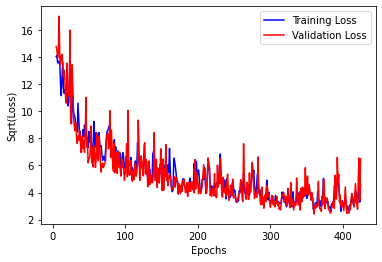

In [11]:
# First create a model for predicting RON/MON
from ecnet import ECNet
from math import sqrt
from matplotlib import pyplot as plt

model = ECNet(dataset_train.desc_vals.shape[1], dataset_train.target_vals.shape[1], 1024, 1, 0.0)
train_loss, valid_loss = model.fit(
    dataset=dataset_train, valid_size=0.25, shuffle=True, verbose=25,
    patience=64, epochs=1024, lr=0.0005, lr_decay=0.0, batch_size=8
)

train_loss = [sqrt(l) for l in train_loss][5:]
valid_loss = [sqrt(l) for l in valid_loss][5:]
epoch = [i for i in range(5, len(train_loss) + 5)]
plt.clf()
plt.xlabel('Epochs')
plt.ylabel('Sqrt(Loss)')
plt.plot(epoch, train_loss, color='blue', label='Training Loss')
plt.plot(epoch, valid_loss, color='red', label='Validation Loss')
plt.legend(loc='upper right')
plt.show()

Epoch: 0 | Train loss: 147.88762025158815 | Valid loss: 9223372036854775807
Epoch: 25 | Train loss: 32.64854218983891 | Valid loss: 39.96823501586914
Epoch: 50 | Train loss: 21.272413012957333 | Valid loss: 24.164756774902344
Epoch: 75 | Train loss: 17.715422849462488 | Valid loss: 18.13043975830078
Epoch: 100 | Train loss: 15.050581368533047 | Valid loss: 15.3013334274292
Epoch: 125 | Train loss: 11.464147818208945 | Valid loss: 11.951199531555176
Epoch: 150 | Train loss: 9.291018197030732 | Valid loss: 9.181048393249512
Epoch: 175 | Train loss: 10.392248211484967 | Valid loss: 7.070704936981201
Epoch: 200 | Train loss: 7.775889199189465 | Valid loss: 10.932640075683594
Epoch: 225 | Train loss: 5.553835665336763 | Valid loss: 4.328891277313232
Epoch: 250 | Train loss: 5.959634607488459 | Valid loss: 4.886524200439453
Epoch: 275 | Train loss: 5.301750746640292 | Valid loss: 4.13408899307251
Epoch: 300 | Train loss: 6.157738825287482 | Valid loss: 5.2307281494140625
Epoch: 325 | Train l

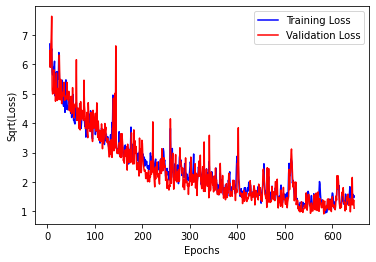

In [12]:
# Now create a model for OS

model_os = ECNet(dataset_os_train.desc_vals.shape[1], dataset_os_train.target_vals.shape[1], 1024, 1, 0.0)
train_loss_os, valid_loss_os = model_os.fit(
    dataset=dataset_os_train, valid_size=0.25, shuffle=True, verbose=25,
    patience=64, epochs=1024, lr=0.0005, lr_decay=0.0, batch_size=8
)

train_loss_os = [sqrt(l) for l in train_loss_os][5:]
valid_loss_os = [sqrt(l) for l in valid_loss_os][5:]
epoch_os = [i for i in range(5, len(train_loss_os) + 5)]
plt.clf()
plt.xlabel('Epochs')
plt.ylabel('Sqrt(Loss)')
plt.plot(epoch_os, train_loss_os, color='blue', label='Training Loss')
plt.plot(epoch_os, valid_loss_os, color='red', label='Validation Loss')
plt.legend(loc='upper right')
plt.show()

In [13]:
# Compare derived OS (pred. RON - pred. MON) to direct OS predictions
from sklearn.metrics import mean_absolute_error, r2_score

y_hat_train = model(dataset_train.desc_vals).detach().numpy()
y_train = dataset_train.target_vals.detach().numpy()
y_hat_test = model(dataset_test.desc_vals).detach().numpy()
y_test = dataset_test.target_vals.detach().numpy()

y_hat_train_os = model_os(dataset_os_train.desc_vals).detach().numpy()
y_train_os = dataset_os_train.target_vals.detach().numpy()
y_hat_test_os = model_os(dataset_os_test.desc_vals).detach().numpy()
y_test_os = dataset_os_test.target_vals.detach().numpy()

y_hat_dos_train = [v[0] - v[1] for v in y_hat_train]
y_dos_train = [v[0] - v[1] for v in y_train]
y_hat_dos_test = [v[0] - v[1] for v in y_hat_test]
y_dos_test = [v[0] - v[1] for v in y_test]

mae_os_train = mean_absolute_error(y_train_os, y_hat_train_os)
mae_os_test = mean_absolute_error(y_test_os, y_hat_test_os)
mae_dos_train = mean_absolute_error(y_dos_train, y_hat_dos_train)
mae_dos_test = mean_absolute_error(y_dos_test, y_hat_dos_test)

r2_os_train = r2_score(y_train_os, y_hat_train_os)
r2_os_test = r2_score(y_test_os, y_hat_test_os)
r2_dos_train = r2_score(y_dos_train, y_hat_dos_train)
r2_dos_test = r2_score(y_dos_test, y_hat_dos_test)

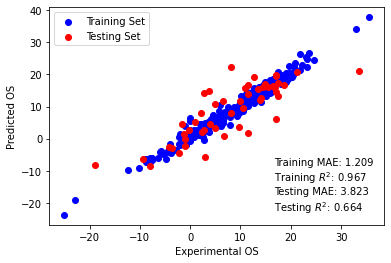

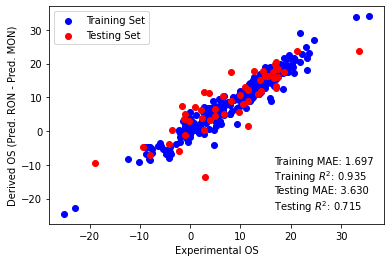

In [14]:
from matplotlib.offsetbox import AnchoredText

plt.clf()
plt.xlabel('Experimental OS')
plt.ylabel('Predicted OS')
plt.scatter(y_train_os, y_hat_train_os, color='blue', label='Training Set')
plt.scatter(y_test_os, y_hat_test_os, color='red', label='Testing Set')
plt.legend(loc='upper left')
string = 'Training MAE: {:.3f}'.format(mae_os_train) + '\n'
string += 'Training $R^2$: {:.3f}'.format(r2_os_train) + '\n'
string += 'Testing MAE: {:.3f}'.format(mae_os_test) + '\n'
string += 'Testing $R^2$: {:.3f}'.format(r2_os_test)
text_box = AnchoredText(string, frameon=True, loc=4, pad=0.5)
plt.setp(text_box.patch, facecolor='white', edgecolor='white')
plt.gca().add_artist(text_box)
plt.show()

plt.clf()
plt.xlabel('Experimental OS')
plt.ylabel('Derived OS (Pred. RON - Pred. MON)')
plt.scatter(y_dos_train, y_hat_dos_train, color='blue', label='Training Set')
plt.scatter(y_dos_test, y_hat_dos_test, color='red', label='Testing Set')
plt.legend(loc='upper left')
string = 'Training MAE: {:.3f}'.format(mae_dos_train) + '\n'
string += 'Training $R^2$: {:.3f}'.format(r2_dos_train) + '\n'
string += 'Testing MAE: {:.3f}'.format(mae_dos_test) + '\n'
string += 'Testing $R^2$: {:.3f}'.format(r2_dos_test)
text_box = AnchoredText(string, frameon=True, loc=4, pad=0.5)
plt.setp(text_box.patch, facecolor='white', edgecolor='white')
plt.gca().add_artist(text_box)
plt.show()